In [51]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [ ]:
df=pd.read_csv('insurance (2).csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [4]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.duplicated().sum()

1

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

0

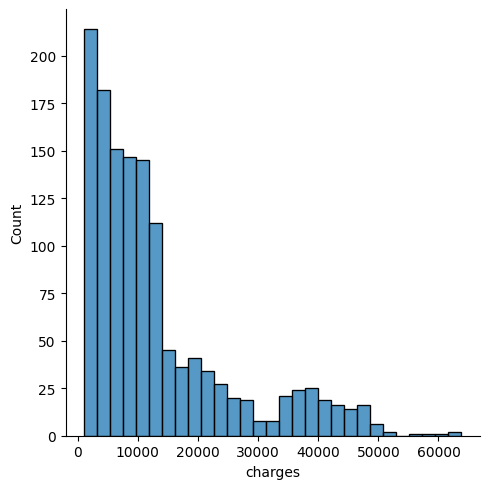

In [10]:
sns.displot(df['charges'])
plt.show()

In [11]:
# one hot encoading
df['sex']=df['sex'].map({'female':0,'male':1})
df['smoker']=df['smoker'].str.lower().map({'yes':1,'no':0})



In [15]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [12]:
df_region=pd.get_dummies(df['region'],dtype=int,drop_first=True)
df_region

,northwest,southeast,southwest
0,0,0,1
1,0,1,0
2,0,1,0
3,1,0,0
4,1,0,0
...,...,...,...
1333,1,0,0
1334,0,0,0
1335,0,1,0
1336,0,0,1


In [13]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [17]:
df_ori=pd.concat([df,df_region],axis=1).drop('region',axis=1)
df_ori

,age,sex,bmi,children,smoker,charges,northwest,southeast,southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,1,0,0
1334,18,0,31.920,0,0,2205.98080,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,1


5 Visualize relationships:
.  Scatter plot of BMI vs Charges


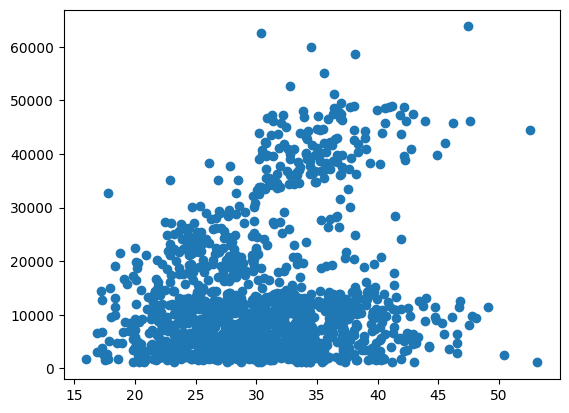

In [18]:
plt.scatter(x=df_ori['bmi'],y=df_ori['charges'])
plt.show()

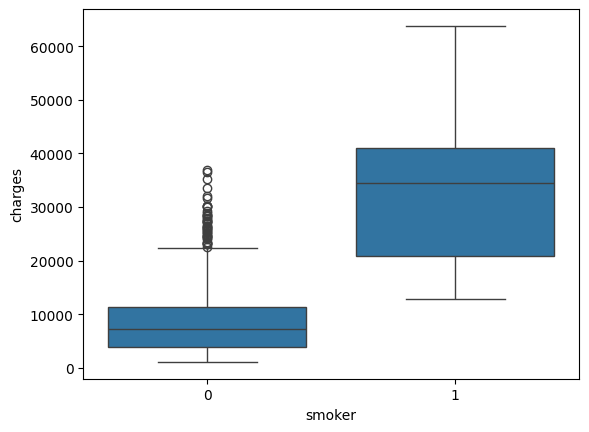

In [20]:
sns.boxplot(data=df_ori,x='smoker',y='charges')
plt.show()

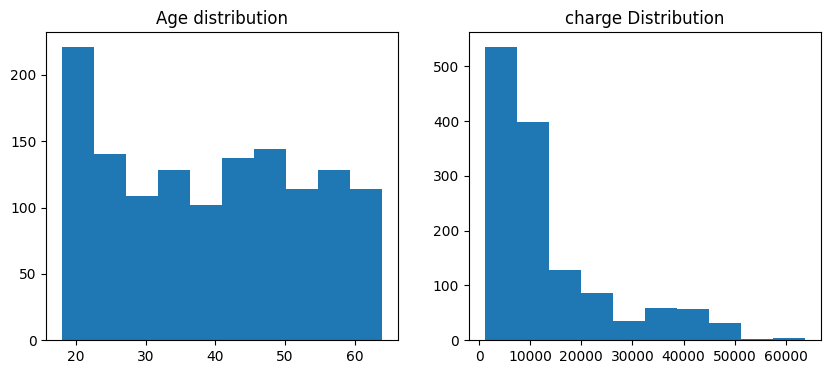

In [25]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df['age'])
plt.title('Age distribution')
plt.subplot(1,2,2)
plt.hist(df['charges'])
plt.title("charge Distribution")
plt.show()


Part B: Multiple Linear Regression Model

In [28]:
df_ori.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'northwest',
       'southeast', 'southwest'],
      dtype='object')

In [33]:
x=df_ori.loc[:,['age','sex','bmi','children','smoker','northwest','southeast','southwest']]
y=df_ori['charges']

In [34]:
# 1.Split the dataset into training (80%) and testing (20%) sets.
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)


In [36]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
y_pred=lr.predict(x_test)


In [40]:
# Evaluate the model using:

r2_score(y_test,y_pred)

0.8069287081198013

In [42]:
mae=mean_absolute_error(y_test,y_pred)
mae

4177.045561036318

In [43]:
mse=mean_squared_error(y_test,y_pred)
mse

35478020.67523558

In [46]:
# 6. Display coefficients and intercept
cofficient=pd.DataFrame({'feature':x.columns,'cofficient':lr.coef_})
print('model cofficient :\n',cofficient)
print('intercept :',lr.intercept_)

model cofficient :
      feature    cofficient
0        age    248.210720
1        sex   -101.542054
2        bmi    318.701441
3   children    533.009989
4     smoker  23077.764593
5  northwest   -391.761455
6  southeast   -838.919616
7  southwest   -659.139752
intercept : -11092.652295945958


Part C: Model Improvement

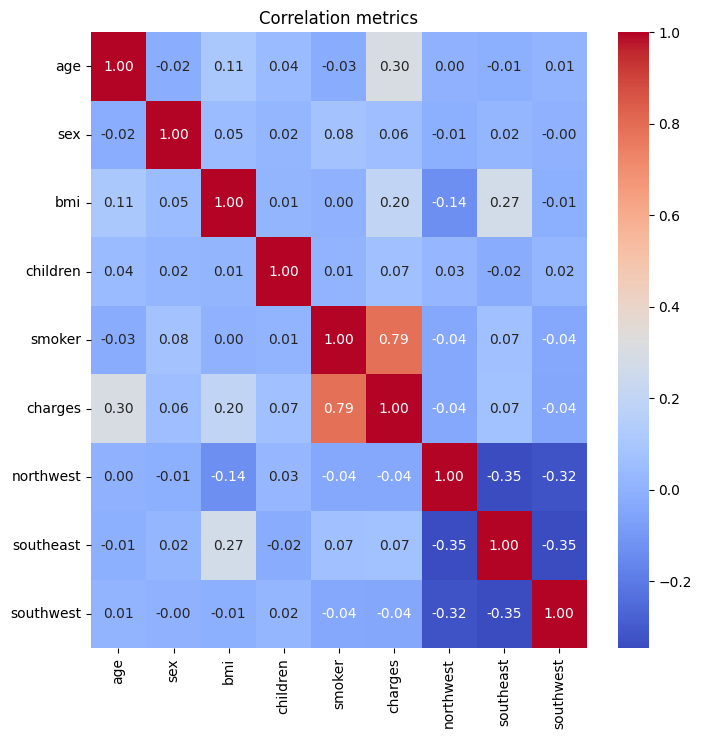

In [ ]:
# Check for multicollinearity among features using correlation matrix.
plt.figure(figsize=(8,8))
sns.heatmap(df_ori.corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title("Correlation metrics")
plt.show()

In [52]:
# Apply feature scaling if necessary and check if model performance improves.
scaler=StandardScaler()
x_scale=scaler.fit_transform(x)

Experiment with dropping insignificant features (if any) and re-evaluate the model.


In [54]:
x_train_s,x_test_s,y_train_s,y_test_s=train_test_split(x_scale,y,test_size=0.2,random_state=42)
model_scaler=LinearRegression()
model_scaler.fit(x_train_s,y_train_s)
y_pred_s=model_scaler.predict(x_test_s)

r2_s=r2_score(y_test_s,y_pred_s)
print(f"R-score after scalling:{r2_s:.4f}")

R-score after scalling:0.8069
